##EDA - exploratory data analysis.

In this section we aim to check for any missing values or outliers while checking for any patterns like numerical or categorical relationships. We do this so that we can find which models are best suited for our dataset and which models will produce the best results in our analysis.

In [221]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df= pd.read_excel("C://Users//tsrap//Downloads//AB_NYC_2019 (1).xlsx")


In [222]:
print("shape of dataset:", df.shape)

shape of dataset: (48895, 16)


In [223]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaT,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [224]:
#print data types
print("\n Data types:\n", df.dtypes)


 Data types:
 id                                         int64
name                                      object
host_id                                    int64
host_name                                 object
neighbourhood_group                       object
neighbourhood                             object
latitude                                 float64
longitude                                float64
room_type                                 object
price                                      int64
minimum_nights                             int64
number_of_reviews                          int64
last_review                       datetime64[ns]
reviews_per_month                        float64
calculated_host_listings_count             int64
availability_365                           int64
dtype: object


In [225]:
#missing values
print(df.isnull().sum().sort_values(ascending=False))

last_review                       10052
reviews_per_month                 10052
host_name                            21
name                                 19
id                                    0
host_id                               0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
calculated_host_listings_count        0
availability_365                      0
dtype: int64


This dataset containts 48,895 entires with 16 features. We se the following listing variables:

1. Price
2. id
3. name
4. host_id
5. host_name
6. neighbourhood_group
7. neighbourhood
8. latitude  
9. longitude
10. room_type
11. price
12. minimum_nights
13. number_of_reviews
14. last_review
15. reviews_per_month
16.calculated_host_listings_count
17. availability_365

We see a mix of numerical, categorical, text and date features. this suggests that we will need to preprocess some of the data (like encoding categorical variables) before applying any machine learning models.

For the missing value analysis we see that both last_review and reviews_per_month each have 10,052 missing values. This indicated that these missing values are likely due to listings with no reviews and we should either fill those missing values as a 0 or remove them depending modeling approach.

In [227]:
print("\nSummary statistics:")
df.describe()



Summary statistics:


,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,2018-10-04 01:47:23.910099456,1.373221,7.143982,112.781327
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,2011-03-28 00:00:00,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,2018-07-08 00:00:00,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,2019-05-19 00:00:00,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2019-06-23 00:00:00,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,2019-07-08 00:00:00,58.500000,327.000000,365.000000
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,NaN,1.680442,32.952519,131.622289


### Price Distribution & Outlier Analysis

C:\Users\tsrap\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



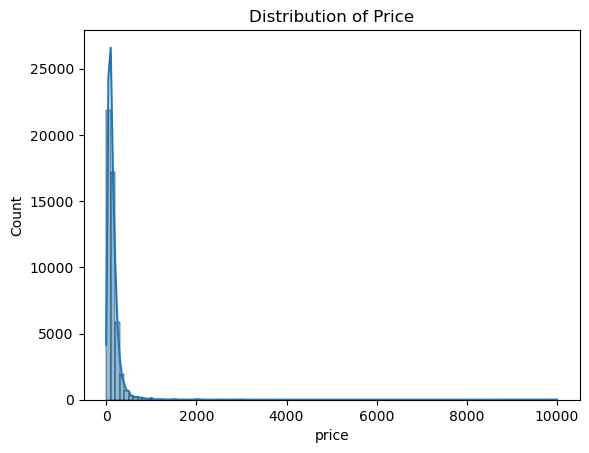

In [229]:
sns.histplot(df["price"], bins=100, kde=True)
plt.title("Distribution of Price")
plt.show()

In [230]:
df[df['price'] > 1000]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
496,174966,Luxury 2Bed/2.5Bath Central Park View,836168,Henry,Manhattan,Upper West Side,40.77350,-73.98697,Entire home/apt,2000,30,30,2018-05-05,0.33,11,0
762,273190,6 Bedroom Landmark West Village Townhouse,605463,West Village,Manhattan,West Village,40.73301,-74.00268,Entire home/apt,1300,5,28,2018-09-25,0.31,4,297
946,363673,Beautiful 3 bedroom in Manhattan,256239,Tracey,Manhattan,Upper West Side,40.80142,-73.96931,Private room,3000,7,0,NaT,NaN,1,365
1105,468613,$ (Phone number hidden by Airbnb) weeks - room f,2325861,Cynthia,Manhattan,Lower East Side,40.72152,-73.99279,Private room,1300,1,0,NaT,NaN,1,0
1480,664047,Lux 2Bed/2.5Bath Central Park Views,836168,Henry,Manhattan,Upper West Side,40.77516,-73.98573,Entire home/apt,2000,30,59,2016-01-28,0.71,11,364
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48080,36074198,Luxury apartment 2 min to times square,203565865,VinÃ­cius,Manhattan,SoHo,40.72060,-74.00023,Entire home/apt,1308,2,0,NaT,NaN,1,179
48304,36189195,Next to Times Square/Javits/MSG! Amazing 1BR!,270214015,Rogelio,Manhattan,Hell's Kitchen,40.75533,-73.99866,Entire home/apt,2999,30,0,NaT,NaN,1,222
48305,36189257,2BR Near Museum Mile! Upper East Side!,272166348,Mary Rotsen,Manhattan,Upper East Side,40.78132,-73.95262,Entire home/apt,1999,30,0,NaT,NaN,1,270
48523,36308562,"Tasteful & Trendy Brooklyn Brownstone, near Train",217732163,Sandy,Brooklyn,Bedford-Stuyvesant,40.68767,-73.95805,Entire home/apt,1369,1,0,NaT,NaN,1,349


In [231]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Upper Bound:", upper_bound)

Upper Bound: 334.0


In [232]:
print("Lower Bound:", lower_bound)

Lower Bound: -90.0


In [233]:
(df["price"] > upper_bound).sum()

2972

In [234]:
((df["price"] > upper_bound).mean()) * 100

6.078331117701197

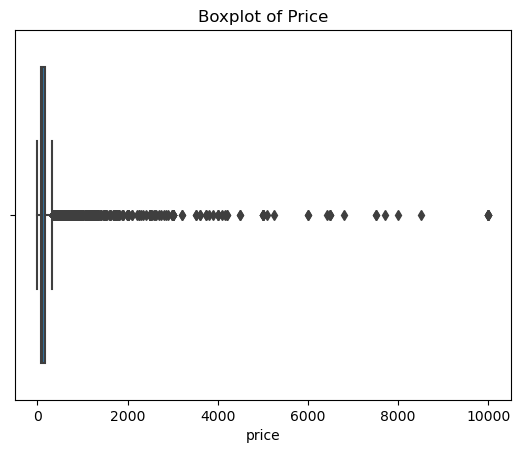

In [235]:
# original boxplot before filtering
sns.boxplot(x=df["price"])

plt.title("Boxplot of Price")

plt.show()

C:\Users\tsrap\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



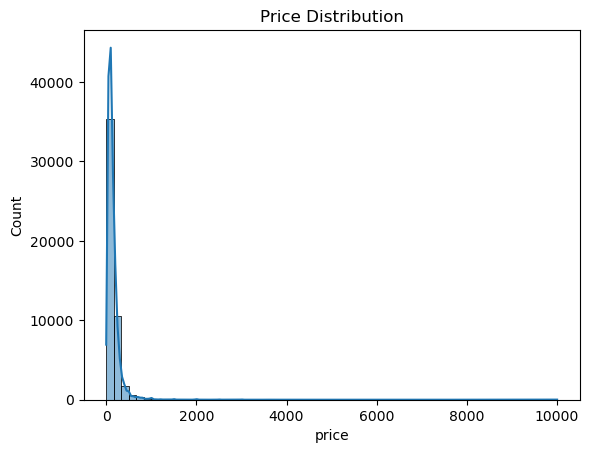

In [236]:
# histogram BEFORE filtering
sns.histplot(df["price"], bins=60, kde=True)

plt.title("Price Distribution")

plt.show()

C:\Users\tsrap\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



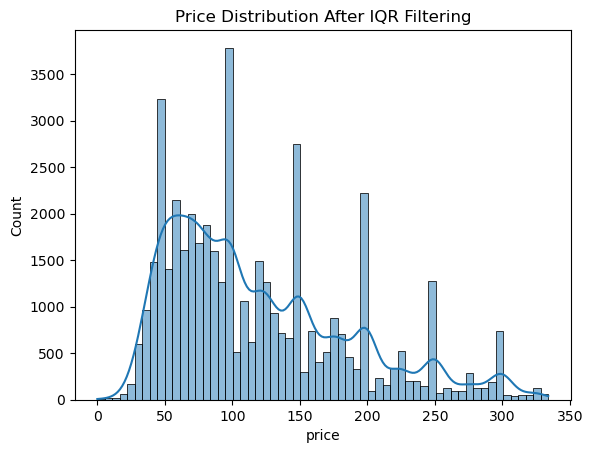

In [237]:
df_price_filtered = df[df["price"] <= upper_bound]

sns.histplot(df_iqr_filtered["price"], bins=60, kde=True)
plt.title("Price Distribution After IQR Filtering")
plt.show()

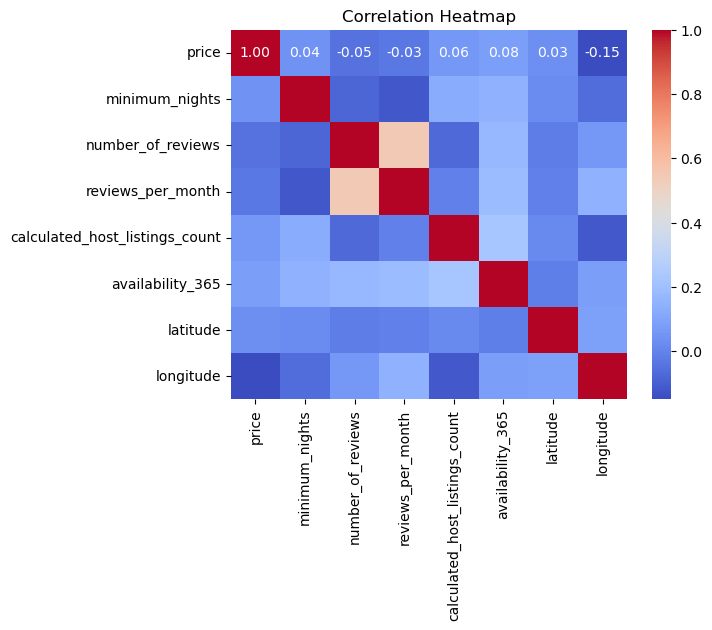

In [238]:
numeric_cols = [
    "price",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "latitude",
    "longitude"
]

corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

The correlation analysis revealed weak relationships between price and numerical features, suggesting that Airbnb pricing is influenced by more complex nonlinear patterns rather than strong linear relationships. 

Strong correlation among review-related features indicates potential multicollinearity, further supporting the use of tree-based machine learning models over linear models.

# Exploratory Business Analysis and Dashboard Development

## 1. Revenue & Pricing Intelligence Dashboard
### Business Question

#### Which locations and property types generate the highest revenue potential?

### Metrics
Average price by borough

Avg price by neighborhood

Top 3 neighborhoods by average price

### Room Type Market Share Analysis
Questions

Which room type dominates NYC?

Which generates highest pricing?

### Required Metrics 
Market share %

Avg price by room type (done)

Avg reviews

Revenue Potential by Room Type (done)

In [241]:
#Categorical feature analysis
print("\nRoom type counts:")
print(df["room_type"].value_counts())

print("\nNeighbourhood group counts:")
print(df["neighbourhood_group"].value_counts())


Room type counts:
room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64

Neighbourhood group counts:
neighbourhood_group
Manhattan        21661
Brooklyn         20104
Queens            5666
Bronx             1091
Staten Island      373
Name: count, dtype: int64


neighbourhood
Willowbrook           249.000000
Neponsit              237.000000
Breezy Point          213.333333
Tribeca               212.495327
NoHo                  205.290909
West Village          193.118644
Flatiron District     188.090909
Financial District    183.973926
Midtown               181.082168
Greenwich Village     180.304094
Name: price, dtype: float64


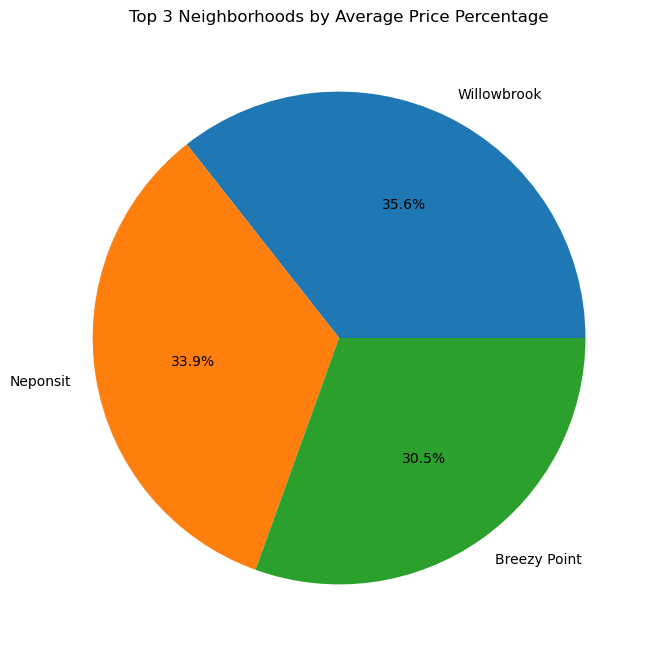


Average Price by Room Type:

room_type
Entire home/apt    162.527096
Private room        79.018503
Shared room         59.293497
Name: price, dtype: float64


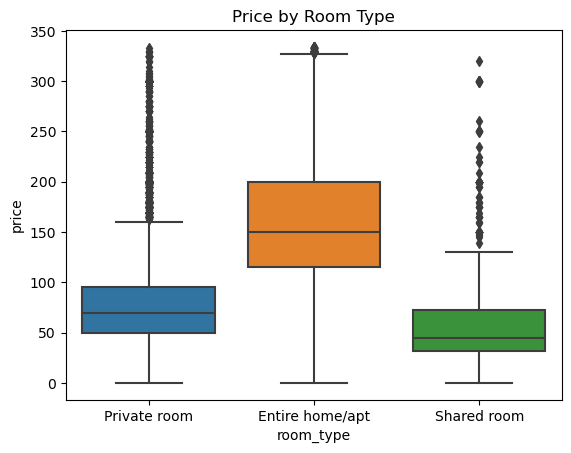


Average price by neighbourhood group:
neighbourhood_group
Manhattan        196.875814
Brooklyn         124.383207
Staten Island    114.812332
Queens            99.517649
Bronx             87.496792
Name: price, dtype: float64


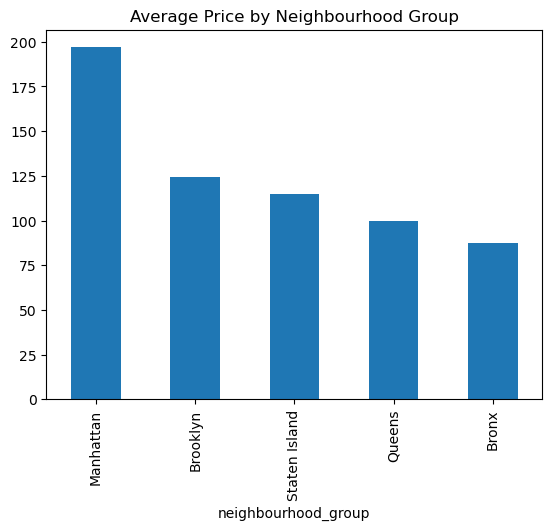

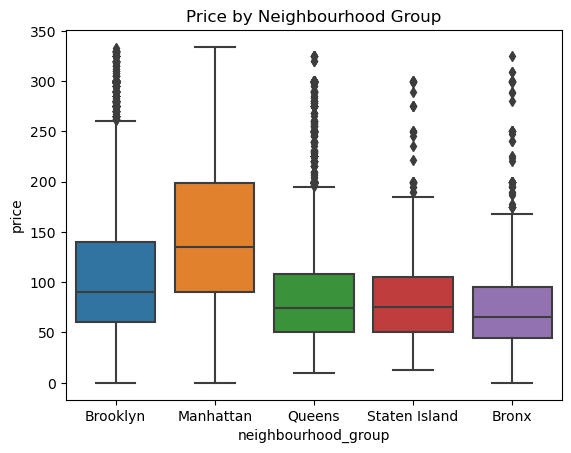

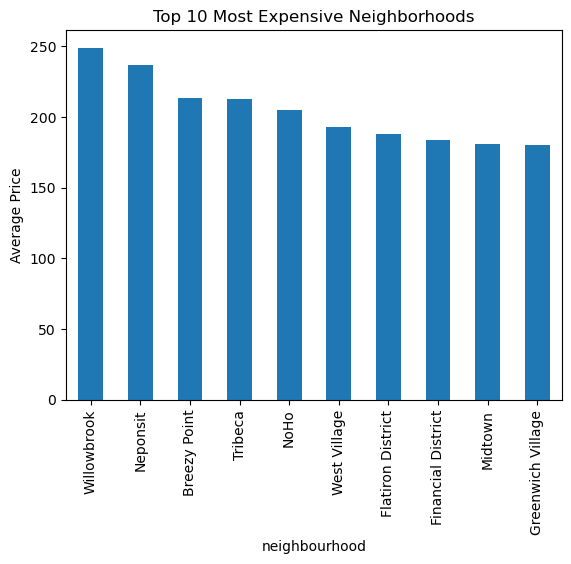

Revenue Potential by Room Type (%)
room_type
Entire home/apt    54.024593
Private room       26.266035
Shared room        19.709372
Name: price, dtype: float64


In [242]:
# Average Price by Neighborhood
avg_price_neighborhood = (
    df_price_filtered.groupby("neighbourhood")["price"]
    .mean()
    .sort_values(ascending=False)
)

print(avg_price_neighborhood.head(10))


# top 3 neighborhoods by average price
top3_neighborhoods = avg_price_neighborhood.head(3)

# convert to percentage
top3_percentage = (top3_neighborhoods / top3_neighborhoods.sum()) * 100

# pie chart
plt.figure(figsize=(8,8))

plt.pie(
    top3_percentage,
    labels=top3_percentage.index,
    autopct='%1.1f%%'
)

plt.title("Top 3 Neighborhoods by Average Price Percentage")

plt.show()

# ---------------------------------------------------------------------------------------------------

# Average Price by Room Type
avg_room_price = df_price_filtered.groupby("room_type")["price"].mean()

print("\nAverage Price by Room Type:\n")

print(avg_room_price)

sns.boxplot(data=df_price_filtered, x="room_type", y="price")
plt.title("Price by Room Type")
plt.show()

#---------------------------------------------------------------------------------------------------------

# Average Price by Borough
avg_price_ng = df.groupby("neighbourhood_group")["price"].mean().sort_values(ascending=False)
print("\nAverage price by neighbourhood group:")
print(avg_price_ng)

avg_price_ng.plot(kind="bar")
plt.title("Average Price by Neighbourhood Group")
plt.show()

# Borough Pricing Comparison Visualization
sns.boxplot(data=df_price_filtered, x="neighbourhood_group", y="price")
plt.title("Price by Neighbourhood Group")
plt.show()

# ------------------------------------------------------------------------------------------------------

# Top 10 Most Expensive Neighborhoods
top10 = avg_price_neighborhood.head(10)

top10.plot(kind="bar")

plt.title("Top 10 Most Expensive Neighborhoods")

plt.ylabel("Average Price")

plt.show()

#----------------------------------------------------------------------------------------------------

# Revenue Potential by Room Type
room_type_avg = df_price_filtered.groupby("room_type")["price"].mean()

# convert to percentage
room_type_percentage = (room_type_avg / room_type_avg.sum()) * 100

print("Revenue Potential by Room Type (%)")
print(room_type_percentage)

In [243]:
# KPI Cards
print("Average Price:", df_price_filtered["price"].mean())

print("Median Price:", df_price_filtered["price"].median())

print("Total Listings:", len(df_price_filtered))

Average Price: 119.97031988328288
Median Price: 100.0
Total Listings: 45923


## Key Findings
Manhattan showed the highest average Airbnb pricing, indicating the strongest revenue potential among all boroughs.

Premium neighborhoods such as Willowbrook, Neponsit, and Breezy Point demonstrated the highest average listing prices.

Entire homes/apartments generated the highest average prices and contributed over 54% of total revenue potential, significantly outperforming private and shared rooms.

## Business Impact
Hosts operating in premium Manhattan neighborhoods can maximize profitability through strategic pricing and premium property offerings.

Investors and hosts may prioritize entire-home listings in high-demand locations to increase revenue generation.

Lower-performing boroughs may require competitive pricing or promotional strategies to improve occupancy and market competitiveness.

## Room Type Market Share Analysis

### Which room type dominates NYC?

Entire homes/apartments dominated the NYC Airbnb market, followed closely by private rooms.

### Which generates the highest pricing?

Entire homes/apartments generated the highest average prices, with significantly higher revenue potential compared to private and shared rooms.
## Key Insights
Entire homes represented the strongest pricing power and customer preference within the NYC Airbnb market.

Shared rooms contributed the smallest market share and lowest average pricing, suggesting lower customer demand.

## Business Impact
Hosts may improve profitability by focusing on full-property rental experiences rather than shared accommodations.

Airbnb operators can optimize pricing strategies by aligning room types with demand-heavy neighborhoods.

High-demand room types in premium boroughs present strong opportunities for revenue optimization and occupancy growth.

### Additional Visualizations

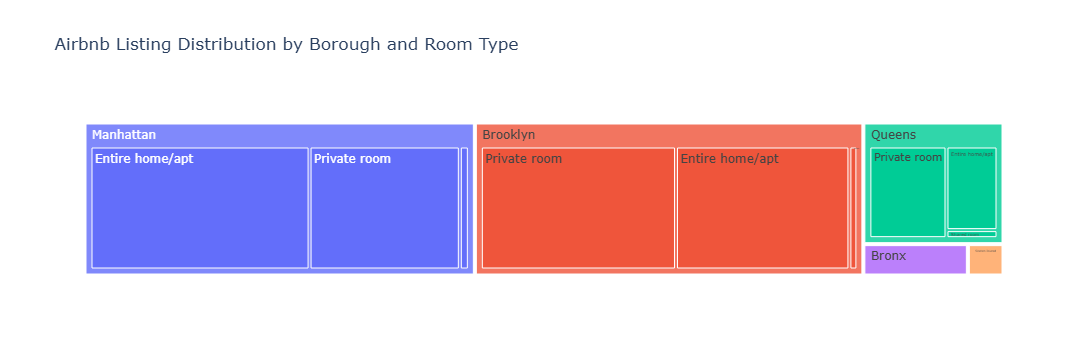

In [357]:
import plotly.express as px

treemap_data = (
    df_price_filtered
    .groupby(
        ["neighbourhood_group", "room_type"]
    )
    .size()
    .reset_index(name="listing_count")
)

fig = px.treemap(
    treemap_data,
    path=["neighbourhood_group", "room_type"],
    values="listing_count",
    title="Airbnb Listing Distribution by Borough and Room Type"
)

fig.show()

In [244]:
#########################################################################################################

## Customer Demand & Occupancy Analysis
### Business Question

What factors indicate high customer demand?

### Use:

availability_365

number_of_reviews

reviews_per_month

### Key Insight
Low availability + high reviews may indicate:

high occupancy
    
strong demand

### Metrics
Availability vs reviews

Price vs occupancy

Room type demand

Average Reviews per Month by Room Type

In [246]:
# Customer Demand & Occupancy Analysis

# summary statistics
print("\nAverage Availability:")
print(df_price_filtered["availability_365"].mean())

print("\nAverage Number of Reviews:")
print(df_price_filtered["number_of_reviews"].mean())

print("\nAverage Reviews Per Month:")
print(df_price_filtered["reviews_per_month"].mean())


Average Availability:
109.3786991267992

Average Number of Reviews:
23.94266489558609

Average Reviews Per Month:
1.378198639971824


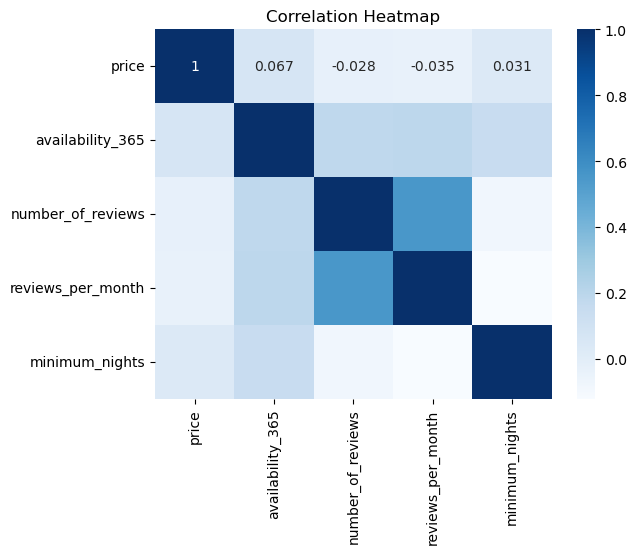


Room Type Demand:

room_type
Entire home/apt    22789
Private room       21996
Shared room         1138
Name: count, dtype: int64


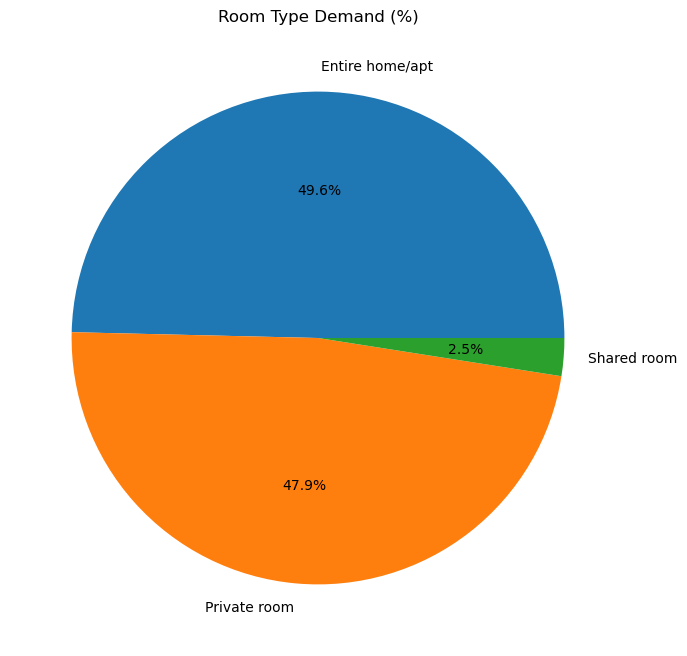

In [247]:
# correlation heatmap

corr_columns = [
    "price",
    "availability_365",
    "number_of_reviews",
    "reviews_per_month",
    "minimum_nights"
]

corr_matrix = df_price_filtered[corr_columns].corr()

sns.heatmap(corr_matrix, annot=True, cmap="Blues")

plt.title("Correlation Heatmap")

plt.show()

# Room Type Demand
room_type_demand = df_price_filtered["room_type"].value_counts()

print("\nRoom Type Demand:\n")

print(room_type_demand)

# Room Type Demand Pie Chart
plt.figure(figsize=(8,8))

plt.pie(
    room_type_demand,
    labels=room_type_demand.index,
    autopct='%1.1f%%'
)

plt.title("Room Type Demand (%)")

plt.show()

C:\Users\tsrap\AppData\Local\Temp\ipykernel_29396\410469639.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\tsrap\AppData\Local\Temp\ipykernel_29396\410469639.py:13: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



availability_category
Low Availability       29.589525
Medium Availability    39.271757
High Availability      33.720908
Name: number_of_reviews, dtype: float64


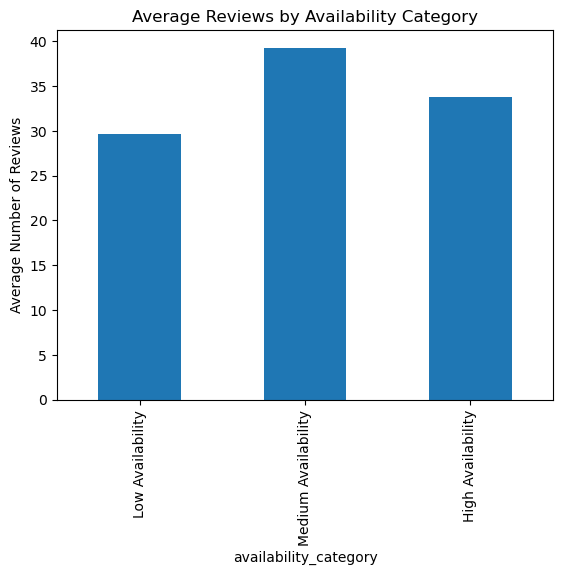

In [248]:
# Average Reviews by Availability Category

# create availability categories
df_price_filtered["availability_category"] = pd.cut(
    df_price_filtered["availability_365"],
    bins=[0, 120, 240, 365],
    labels=["Low Availability", "Medium Availability", "High Availability"]
)

# average reviews by availability category

reviews_availability = (
    df_price_filtered.groupby("availability_category")["number_of_reviews"]
    .mean()
)

print(reviews_availability)

reviews_availability.plot(kind="bar")

plt.title("Average Reviews by Availability Category")

plt.ylabel("Average Number of Reviews")

plt.show()

C:\Users\tsrap\AppData\Local\Temp\ipykernel_29396\1488427393.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



availability_category
Low Availability       119.016922
Medium Availability    125.388062
High Availability      126.751717
Name: price, dtype: float64


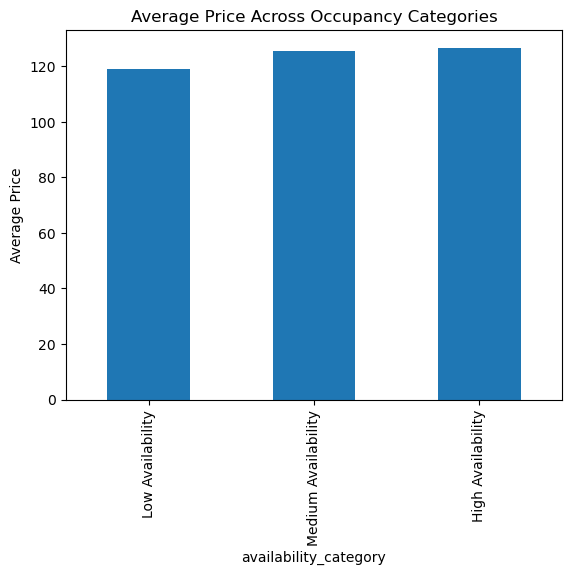

In [249]:
# Price vs occupancy (Availability groups that we created)
avg_price_availability = (
    df_price_filtered.groupby("availability_category")["price"]
    .mean()
)

print(avg_price_availability)

avg_price_availability.plot(kind="bar")

plt.title("Average Price Across Occupancy Categories")

plt.ylabel("Average Price")

plt.show()

room_type
Entire home/apt    1.305824
Private room       1.449938
Shared room        1.484528
Name: reviews_per_month, dtype: float64


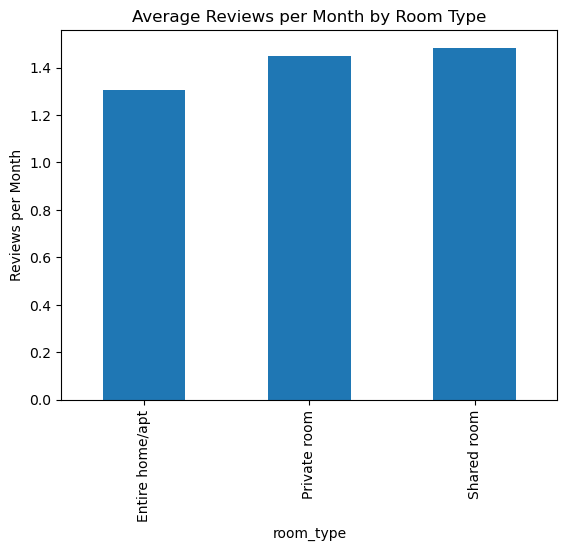

In [250]:
reviews_room = (
    df_price_filtered.groupby("room_type")["reviews_per_month"]
    .mean()
)

print(reviews_room)

reviews_room.plot(kind="bar")

plt.title("Average Reviews per Month by Room Type")

plt.ylabel("Reviews per Month")

plt.show()

Listings with medium availability received the highest customer engagement, averaging 39.3 reviews, compared to 29.6 reviews for low availability listings. This suggests that moderately available properties may experience stronger and more consistent booking demand.

Listings with high availability had the highest average price at approximately 126.75, while low availability listings averaged around $119.02.

Shared rooms generated the highest average reviews per month (1.48 reviews/month), followed by private rooms (1.45), indicating stronger recurring customer activity compared to entire homes/apartments (1.31).

### Overall marketplace activity showed:
Average availability: 109.4 days/year

Average reviews per listing: 23.9

Average reviews per month: 1.38

## Business Improvement Opportunities
1. Optimize pricing strategies for highly available listings to improve occupancy rates.

2. Increase visibility and promotions for low-engagement listings to attract more bookings.

3. Focus marketing efforts on room types with stronger customer engagement patterns, such as private and shared rooms.

In [251]:
#############################################################################################################

## Geographic Intelligence Dashboard

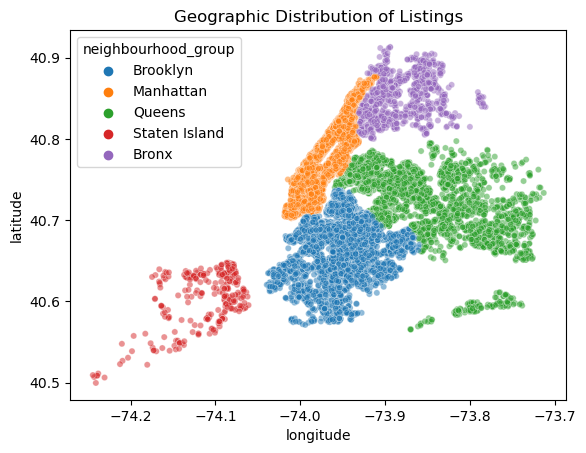

In [253]:
sns.scatterplot(data=df, x="longitude", y="latitude", hue="neighbourhood_group", alpha=0.5, s=20)
plt.title("Geographic Distribution of Listings")
plt.show()

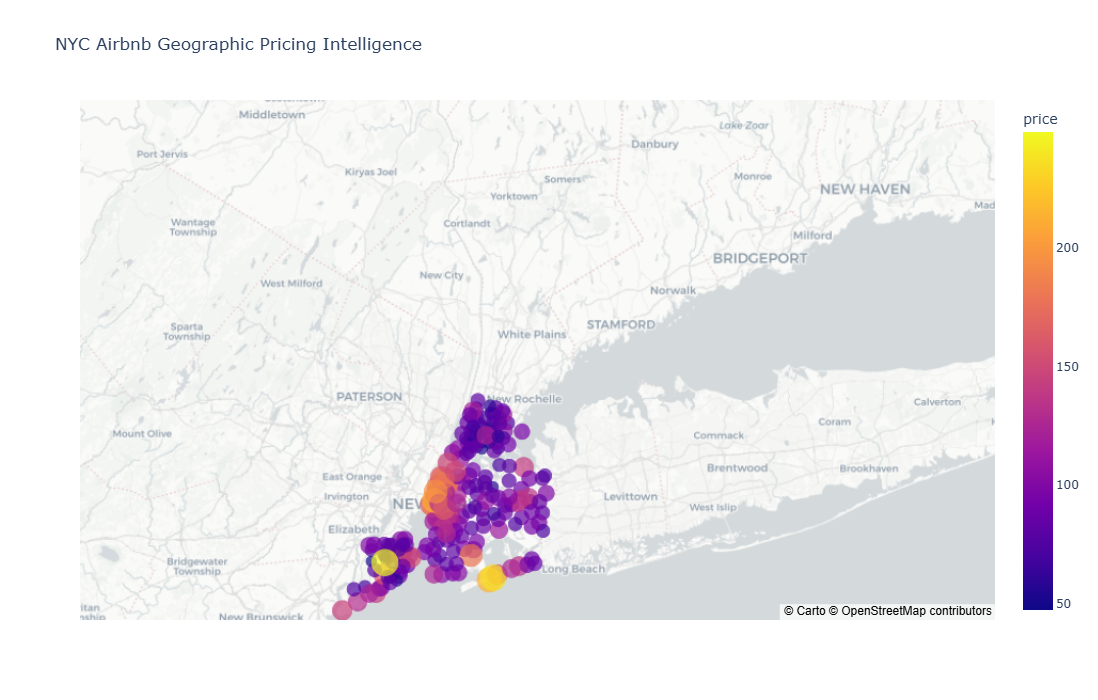

In [254]:
import plotly.express as px
# average price by neighbourhood

avg_price_map = (
    df_price_filtered.groupby("neighbourhood")
    .agg({
        "price": "mean",
        "number_of_reviews": "mean",
        "reviews_per_month": "mean",
        "latitude": "mean",
        "longitude": "mean"
    })
    .reset_index()
)

# choropleth-style geographic bubble map

fig = px.scatter_mapbox(
    avg_price_map,
    lat="latitude",
    lon="longitude",
    size="price",
    color="price",
    hover_name="neighbourhood",
    hover_data={
        "price": True,
        "number_of_reviews": True,
        "reviews_per_month": True
    },
    zoom=10,
    height=700,
    title="NYC Airbnb Geographic Pricing Intelligence"
)

fig.update_layout(
    mapbox_style="carto-positron"
)

fig.show()

## Geographic Analysis Interpretation:

Here, we developed an interactive geographic pricing intelligence map to analyze Airbnb market trends across NYC neighborhoods. 
The visualization highlights geographic pricing concentration, customer engagement, and demand patterns by mapping average listing prices, review activity, and neighborhood-level metrics. 

Larger and darker bubbles represent neighborhoods with stronger pricing potential, revealing that premium-priced listings are heavily concentrated in high-demand urban areas such as Manhattan and central NYC regions.

In [255]:
#################################################################################################################

## Availability Optimization Analysis

### Questions
Which listings are over-available?

Which properties appear underutilized?

### Strong Business Interpretation

#### High availability may indicate:

Lower demand

Pricing issues

Weak occupancy

#### Low availability may indicate:

Strong demand

Effective pricing strategy

### Dashboard KPI
Avg availability by neighborhood

Availability vs pricing

In [257]:
# Average availability by neighbourhood

avg_availability = (
    df_price_filtered.groupby("neighbourhood")["availability_365"]
    .mean()
    .sort_values(ascending=False)
)

print("\nAverage Availability by Neighbourhood:\n")

print(avg_availability.head(10))


Average Availability by Neighbourhood:

neighbourhood
Co-op City        364.000000
Willowbrook       351.000000
Spuyten Duyvil    336.333333
Eastchester       331.333333
Richmondtown      300.000000
Mill Basin        290.000000
Edgemere          275.272727
West Brighton     274.722222
Randall Manor     271.388889
Tottenville       267.571429
Name: availability_365, dtype: float64


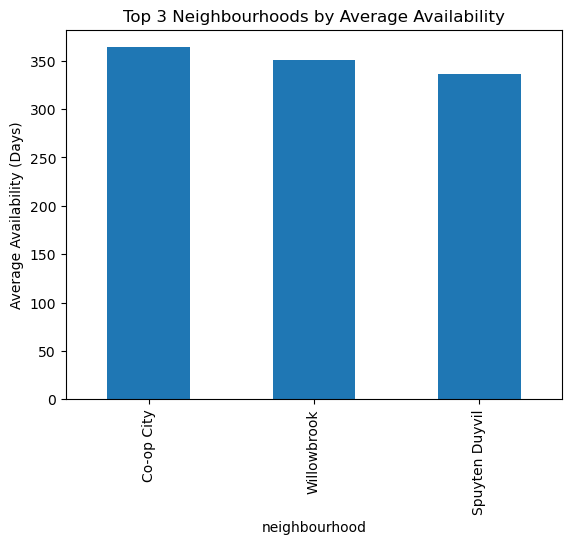

In [258]:
# Top 3 most available (potentially underutilized) neighbourhoods

top_available = avg_availability.head(3)

top_available.plot(kind="bar")

plt.title("Top 3 Neighbourhoods by Average Availability")

plt.ylabel("Average Availability (Days)")

plt.show()

In [259]:
# average price by availability category

avg_price_availability = (
    df_price_filtered.groupby("availability_category")["price"]
    .mean()
)

print("\nAverage Price by Availability Category:\n")

print(avg_price_availability)


Average Price by Availability Category:

availability_category
Low Availability       119.016922
Medium Availability    125.388062
High Availability      126.751717
Name: price, dtype: float64


C:\Users\tsrap\AppData\Local\Temp\ipykernel_29396\2614058274.py:4: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



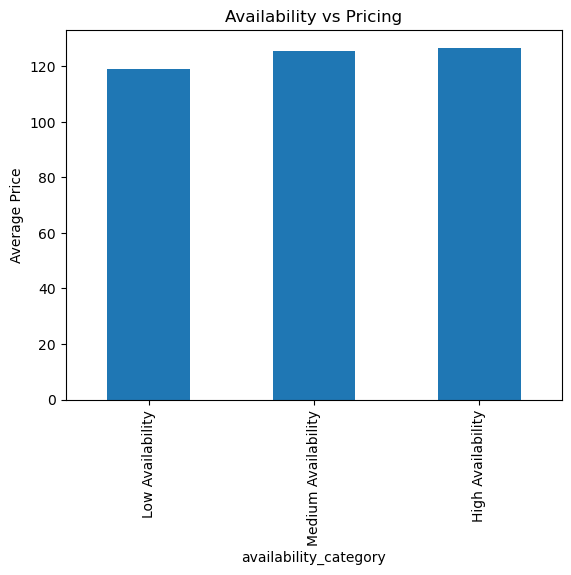

In [260]:
# Availability vs Pricing chart

avg_price_availability.plot(kind="bar")

plt.title("Availability vs Pricing")

plt.ylabel("Average Price")

plt.show()

In [261]:
# average reviews by availability category

reviews_availability = (
    df_price_filtered.groupby("availability_category")["number_of_reviews"]
    .mean()
)

print("\nAverage Reviews by Availability Category:\n")

print(reviews_availability)


Average Reviews by Availability Category:

availability_category
Low Availability       29.589525
Medium Availability    39.271757
High Availability      33.720908
Name: number_of_reviews, dtype: float64


C:\Users\tsrap\AppData\Local\Temp\ipykernel_29396\1571733779.py:4: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



C:\Users\tsrap\AppData\Local\Temp\ipykernel_29396\2024941484.py:4: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.




Average Reviews by Availability Category:

availability_category
Low Availability       29.589525
Medium Availability    39.271757
High Availability      33.720908
Name: number_of_reviews, dtype: float64

Customer Demand by Availability Level (%):

availability_category
Low Availability       28.844700
Medium Availability    38.283212
High Availability      32.872088
Name: number_of_reviews, dtype: float64


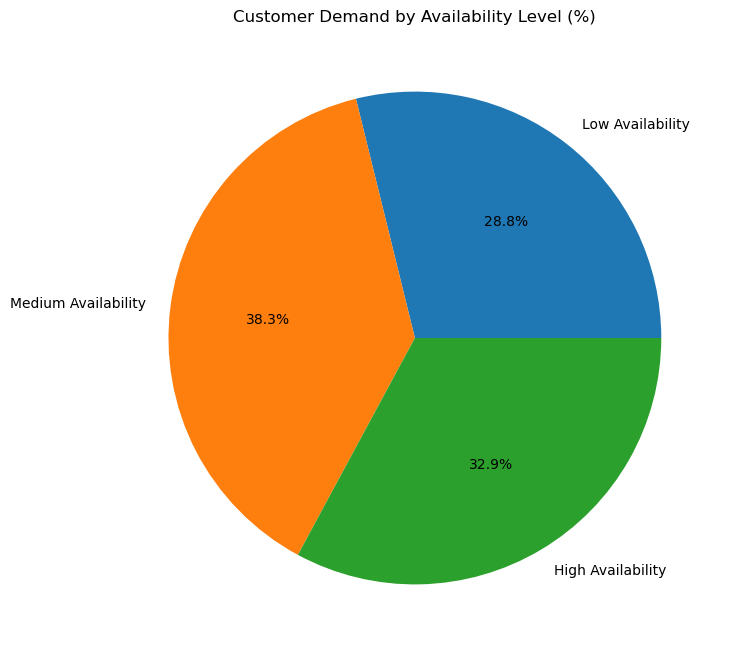

In [262]:
# average reviews by availability category

reviews_availability = (
    df_price_filtered.groupby("availability_category")["number_of_reviews"]
    .mean()
)

print("\nAverage Reviews by Availability Category:\n")

print(reviews_availability)


# convert average reviews to percentage

reviews_percentage = (
    reviews_availability / reviews_availability.sum()
) * 100

print("\nCustomer Demand by Availability Level (%):\n")

print(reviews_percentage)
plt.figure(figsize=(8,8))

plt.pie(
    reviews_percentage,
    labels=reviews_percentage.index,
    autopct='%1.1f%%'
)

plt.title("Customer Demand by Availability Level (%)")

plt.show()

In [263]:
####################################################################################################

In [264]:
corr_target = df[numeric_cols].corr()["price"].sort_values(ascending=False)
print(corr_target)

price                             1.000000
availability_365                  0.081829
calculated_host_listings_count    0.057472
minimum_nights                    0.042799
latitude                          0.033939
reviews_per_month                -0.030608
number_of_reviews                -0.047954
longitude                        -0.150019
Name: price, dtype: float64


There is no strong linear relationship between price and any single numerical feature. Price is likely influenced by multiple features interacting together, rather than one dominant factor

Therefore, the correlation analysis shows that price does not have a strong linear relationship with any numerical feature, indicating that more complex, nonlinear models are needed to capture the underlying patterns.

C:\Users\tsrap\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



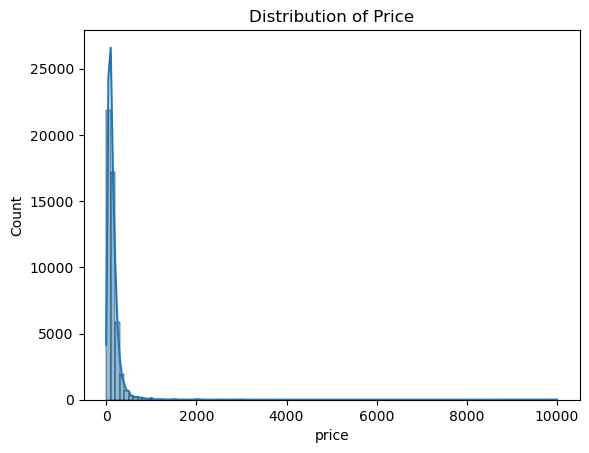

C:\Users\tsrap\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



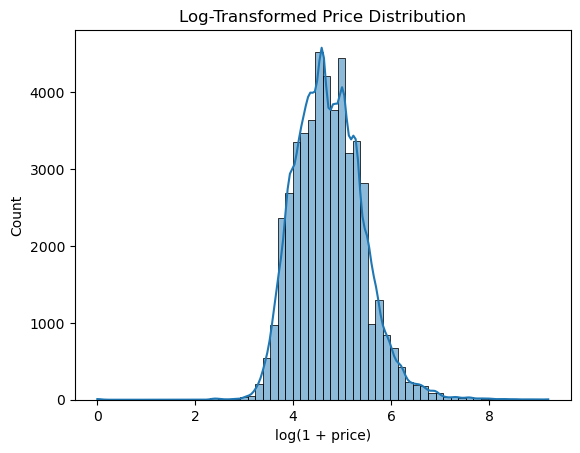

In [266]:
sns.histplot(df["price"], bins=100, kde=True)
plt.title("Distribution of Price")
plt.show()
#log transformation for price
df["log_price"] = np.log1p(df["price"])
sns.histplot(df["log_price"], bins=60, kde=True)
plt.title("Log-Transformed Price Distribution")
plt.xlabel("log(1 + price)")
plt.show()


We applied a log transformation to price to help reduce skewness, and as show in the plot above we can see the vast improvement in the plots. We went from extremem skewness to a more normal distribution like plot whihc is more suitable for modeling.



Overall EDA reveals that our dataset needs some cleaning up to do, we need to deal with some outliers, missing values, and fix the weak relationship between numerical features and price. We saw from the geographic clustering that location plays a huge role in determining what price certain listings will be. Based on all these findings we can conclude that usuing nonlinear models like Randosm Forest and Gradient Boosting will yeild us the best results and simple linear models will not capture the comples interactions and handle the extreme outliers we saw.

## Data preprocessing

In this sectionwe will fix some inconsistencies in our data that we found in our exploratory data analysis section. For example we found missing values in last_review and reviews_per month. We see a strong skew in our target vairable, price (which we fixed with a log transformation).

In [308]:
df_price_filtered.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,availability_category
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365,High Availability
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,High Availability
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaT,NaN,1,365,High Availability
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,Medium Availability
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0,NaN


In [310]:
# make a copy of the outlier-filtered dataset
df_model = df_price_filtered.copy()

#identify target (use log price)
df_model["log_price"] = np.log1p(df_model["price"])

#convert stringg to datetime object for pandas
df_model["last_review"] = pd.to_datetime(df_model["last_review"], errors="coerce")

max_date = df_model["last_review"].max()

df_model["days_since_last_review"] = (max_date - df_model["last_review"]).dt.days

In [312]:
df_model.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,availability_category,log_price,days_since_last_review
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365,High Availability,5.010635,262.0
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,High Availability,5.420535,48.0
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaT,NaN,1,365,High Availability,5.017280,NaN
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,Medium Availability,4.499810,3.0
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0,NaN,4.394449,231.0


In [314]:
df_model.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365', 'availability_category', 'log_price',
       'days_since_last_review'],
      dtype='object')

In [316]:
#filling missing reviews with 0 and -1
df_model["reviews_per_month"] = (
    df_model["reviews_per_month"].fillna(0)
)

df_model["days_since_last_review"] = (
    df_model["days_since_last_review"].fillna(-1)
)

# drop unnecessary features
features_to_drop = [
    "price",
    "log_price",
    "id",
    "host_id",
    "name",
    "host_name",
    "last_review",
    "availability_category"
]

#now we need to drop some features (target and identifiers)
X = df_model.drop(columns=features_to_drop)

y = df_model["log_price"]

#distinguish between categorical and numerical variables
# categorical variables
categorical_cols = [
    "neighbourhood_group",
    "neighbourhood",
    "room_type"
]

# numerical variables
numeric_cols = [
    "latitude",
    "longitude",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "days_since_last_review"
]

Since observed many outliers and varying feature distributions in many of our plots for numerical and categorical data, we want to feature scale the variables. We are going to impute data for the Numerical features by using the median (median is more robust to outliers) so that we reduce the impact of the outliers we saw before. We also will encode categorical variables using one hot encoding  (so that the model can easily interpret categorical variables in numeric format)

In [319]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))])

#combine the results
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)])


In [321]:
from sklearn.model_selection import train_test_split

#now we will split the data 80% training 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

#check for shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

#fit + transform
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape:", X_test_processed.shape)

X_train shape: (36738, 11)
X_test shape: (9185, 11)
y_train shape: (36738,)
y_test shape: (9185,)
Processed X_train shape: (36738, 235)
Processed X_test shape: (9185, 235)


After preprocessing, the number of features increased significantly from 11 to 234 due to one-hot encoding of categorical variables. This transformation introduced high dimensionality into the dataset, which can impact model performance and makes tree-based models more suitable for capturing complex relationships.

### After thoughts

After completing some data preprocessing, we then splits our data (80% training 20% testing) and printed out the shapes /processed data shapes to see if the one-hot encoding and feature scaling had any affect on our data. In this section we filled missing values, imputed and encode our numerical and categorical data while taking care of outliers.

## Model Building

In [326]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=10),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=10),
    "Gradient Boosting": GradientBoostingRegressor(random_state=10)
}

In [328]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

results = {}

for name, model in models.items():
    # Train model
    model.fit(X_train_processed, y_train)

    # Predict
    y_pred = model.predict(X_test_processed)

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Store results
    results[name] = {
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }

    # Print results
    print(f"\n{name}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R2: {r2:.4f}")


Linear Regression
RMSE: 0.3680
MAE: 0.2820
R2: 0.5882

Decision Tree
RMSE: 0.4839
MAE: 0.3608
R2: 0.2882

Random Forest
RMSE: 0.3484
MAE: 0.2623
R2: 0.6311

Gradient Boosting
RMSE: 0.3511
MAE: 0.2691
R2: 0.6251


In [333]:
import pandas as pd

results_df = pd.DataFrame(results).T
print("\nModel Comparison:")
print(results_df)



Model Comparison:
                       RMSE       MAE        R2
Linear Regression  0.368049  0.281999  0.588151
Decision Tree      0.483851  0.360786  0.288214
Random Forest      0.348351  0.262311  0.631057
Gradient Boosting  0.351137  0.269127  0.625132


In [335]:
results_df.sort_values(by="RMSE")

,RMSE,MAE,R2
Random Forest,0.348351,0.262311,0.631057
Gradient Boosting,0.351137,0.269127,0.625132
Linear Regression,0.368049,0.281999,0.588151
Decision Tree,0.483851,0.360786,0.288214


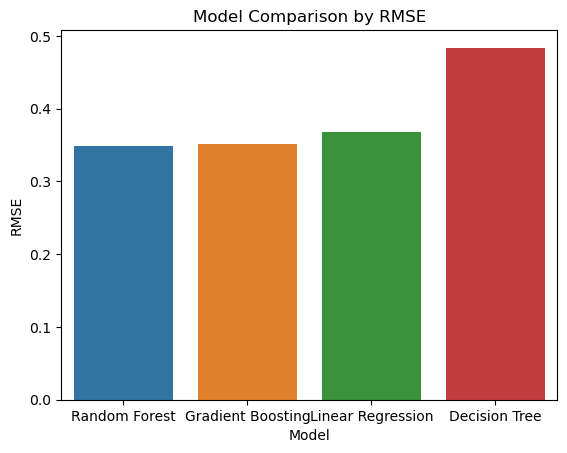

In [339]:
#visualize model comparision

results_df = results_df.sort_values(by="RMSE")

sns.barplot(x=results_df.index, y=results_df["RMSE"])
plt.title("Model Comparison by RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.show()

### Random Forest (Best Model)
Random Forest achieved the best overall performance. This is expected because:

It handles nonlinear relationships well
It is robust to outliers, which we observed in the price distribution
It works effectively with high-dimensional data (234 features after encoding)

*  It handles nonlinear relationships well
*  It is robust to outliers, which we observed in the price distribution
*  It works effectively with high-dimensional data (234 features after encoding)

### Gradient Boosting (Close Second)

Gradient Boosting also performed well and was close to Random Forest.
It is a powerful model that:

*   Builds models sequentially to reduce errors
*   Captures complex patterns in the data

However, it slightly underperformed compared to Random Forest in this case.

### Linear Regression (Moderate Performance)

Linear Regression performed worse than the tree-based models. This aligns with our earlier EDA findings:

We observed weak linear correlations between price and numerical features
This means a linear model cannot fully capture the relationships in the data

###Decision Tree (Worst Model)

The Decision Tree model had the worst performance. This is likely because:

* It tends to overfit the training data
* It does not generalize well compared to ensemble methods like Random Forest

In [342]:
# based off the fact that we picked Random Forest as our best model we wil perform
#some feature importance on it

best_model = models["Random Forest"]

feature_names = preprocessor.get_feature_names_out()

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance.head(15))

                                   Feature  Importance
232         cat__room_type_Entire home/apt    0.431381
0                            num__latitude    0.123701
1                           num__longitude    0.114439
6                    num__availability_365    0.055278
7              num__days_since_last_review    0.043703
10      cat__neighbourhood_group_Manhattan    0.041307
4                   num__reviews_per_month    0.040949
2                      num__minimum_nights    0.039460
3                   num__number_of_reviews    0.032828
5      num__calculated_host_listings_count    0.024132
233            cat__room_type_Private room    0.007455
234             cat__room_type_Shared room    0.004376
26   cat__neighbourhood_Bedford-Stuyvesant    0.003450
226        cat__neighbourhood_Williamsburg    0.001941
139             cat__neighbourhood_Midtown    0.001405


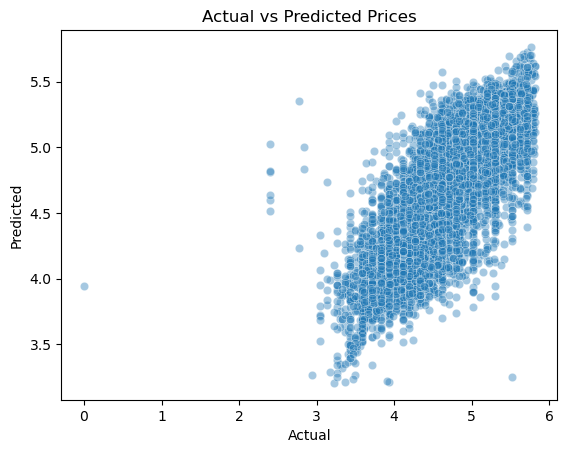

In [344]:
y_pred = best_model.predict(X_test_processed)

sns.scatterplot(x=y_test, y=y_pred, alpha=0.4)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Prices")
plt.show()

To further analyze our best performing model we analyzed the prdiction accuracy and feature importance using the Random Forest Regressor.

In the actual vs predicted price scatterplot we see a positive relationship between true price and predicted price. This means that as the AirBnb prices increase the predicted prices is also increasing which indicated that model is good at capturing the pricing pattern. We do see a few outliers which may be true outlier or error, but this is expected bahvior from a housing dataset as there are many complex factors.

For feature importance, we see which variable have the most influence on price predictions. The most important predictor was Entire home/apartment room type (40.3%), while the second and third most important predictors were Longitude and Latitiude which indicated that location is very crutical in determining price for AirBnbs.

Overall in this analysis we found that room type and geogrpahic location plays a critical role in Airbnb price predicition. This aligns with our exploratory data analysis where we analyzed that room type and neighborhood was visally affecting price.